# Parental leave policies analysis using Pandas

Author: Ye Joo Park ([ypark32@illinois.edu](mailto:ypark32@illinois.edu))

- Data Source:
    - Original source: [FairyGodBoss](https://fairygodboss.com/maternity-leave-resource-center)
    - Compiled by [Maven Analytics](https://www.mavenanalytics.io/data-playground)

Paid leave after a child's birth is one of the most visible benefits an employer offers, and one of the clearest places where mothers and fathers are treated differently. The U.S. has no federal paid-leave mandate. The [Family and Medical Leave Act (FMLA)](https://www.dol.gov/agencies/whd/fmla) guarantees eligible employees up to 12 weeks of **unpaid**, job-protected leave, so how much *paid* leave parents get is largely up to their employer.

This notebook uses crowdsourced parental leave policies for ~1,600 companies, reported by users of [FairyGodBoss](https://fairygodboss.com/maternity-leave-resource-center) (a career community for women) and compiled by [Maven Analytics](https://www.mavenanalytics.io/data-playground). The storyline follows **the gender gap in paid parental leave and where it is closing**:

1. How much paid maternity leave do companies offer, and why do policies cluster at certain lengths?
2. How big is the gap between paid maternity and paid paternity leave *at the same company*?
3. Where is the gap closing: at which generosity levels and in which industries do mothers and fathers get the same paid leave?
4. Do companies use unpaid leave as a substitute for paid leave?
5. Which employers stand out?

> ⚠️ **Data caveat:** These numbers are self-reported by site users, not taken from official policy documents. Users of a career site for women are not a random sample of employees, and well-known employers are more likely to be reported. The results describe *this sample of reported policies*, not all employers.

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_colwidth', 200)

In [3]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats

pio.templates['sans_serif'] = go.layout.Template(dict(layout=go.Layout(
    font_family='Helvetica, Inter, Arial, sans-serif')))
pio.templates.default = 'simple_white+sans_serif'

# Colors used throughout: one for mothers, one for fathers, black for emphasis, gray for context
MOM_COLOR = '#C2410C'
DAD_COLOR = '#1D4ED8'
GRAY = '#BDBDBD'

pd.set_option('display.max_columns', 20)

## 📥 Load and Prepare the Data

In [4]:
dd = pd.read_csv('data_dictionary.csv')
dd

,Field,Description
0,Company,Company name
1,Industry,Company industry & sub-industry (Industry: Sub-industry)
2,Paid Maternity Leave,Paid weeks off from work for mothers after the birth of their child
3,Unpaid Maternity Leave,Unpaid weeks off from work for mothers after the birth of their child
4,Paid Paternity Leave,Paid weeks off from work for fathers after the birth of their child
5,Unpaid Paternity Leave,Unpaid weeks off from work for fathers after the birth of their child
6,NaN,"NOTE: This is user-reported data. Where users report conflicting information, consensus numbers (if any) or the median are shown. ""N/A"" means no information has been reported."


In [5]:
df = pd.read_csv('parental_leave.csv')
df.rename(columns={
    'Industry': 'Industry & Sub-industry'
}, inplace=True)
df

,Company,Industry & Sub-industry,Paid Maternity Leave,Unpaid Maternity Leave,Paid Paternity Leave,Unpaid Paternity Leave
0,Epsilon,Advertising,6.0,6.0,6.0,6.0
1,The Walt Disney Company,Arts & Entertainment,5.0,4.0,4.5,4.0
2,Guild Education,Business Services: Other,14.0,0.0,8.0,4.0
3,WeWork,Business Services: Other,14.0,2.0,16.0,4.0
4,Randstad USA,Business Services: Staffing & Outsourcing,5.0,7.0,0.0,0.0
...,...,...,...,...,...,...
1596,Xero,Technology: Software,6.0,NaN,NaN,NaN
1597,Fedex Supply Chain,Transportation: Freight & Logistics,2.0,NaN,NaN,NaN
1598,Schneider National,Transportation: Freight & Logistics,0.0,NaN,NaN,NaN
1599,HD Supply,Wholesale,14.0,NaN,NaN,NaN


In [6]:
df['Industry & Sub-industry'].value_counts()

Industry & Sub-industry
Technology: Software                            160
Technology: Consumer Internet                    64
Educational Services: College & Universities     52
Advertising                                      50
Consulting Services                              47
                                               ... 
Technology                                        1
Textiles                                          1
Transportation: Bus                               1
Utilities                                         1
Maritime                                          1
Name: count, Length: 185, dtype: int64

In [7]:
df['Industry'] = df['Industry & Sub-industry'].str.split(':').str[0].str.strip()
df['Sub-industry'] = df['Industry & Sub-industry'].str.split(':').str[1].str.strip()

In [8]:
df

,Company,Industry & Sub-industry,Paid Maternity Leave,Unpaid Maternity Leave,Paid Paternity Leave,Unpaid Paternity Leave,Industry,Sub-industry
0,Epsilon,Advertising,6.0,6.0,6.0,6.0,Advertising,NaN
1,The Walt Disney Company,Arts & Entertainment,5.0,4.0,4.5,4.0,Arts & Entertainment,NaN
2,Guild Education,Business Services: Other,14.0,0.0,8.0,4.0,Business Services,Other
3,WeWork,Business Services: Other,14.0,2.0,16.0,4.0,Business Services,Other
4,Randstad USA,Business Services: Staffing & Outsourcing,5.0,7.0,0.0,0.0,Business Services,Staffing & Outsourcing
...,...,...,...,...,...,...,...,...
1596,Xero,Technology: Software,6.0,NaN,NaN,NaN,Technology,Software
1597,Fedex Supply Chain,Transportation: Freight & Logistics,2.0,NaN,NaN,NaN,Transportation,Freight & Logistics
1598,Schneider National,Transportation: Freight & Logistics,0.0,NaN,NaN,NaN,Transportation,Freight & Logistics
1599,HD Supply,Wholesale,14.0,NaN,NaN,NaN,Wholesale,NaN


In [9]:
df['Industry'].value_counts()

Industry
Technology                     327
Finance                        112
Healthcare                      98
Educational Services            90
Retail                          79
Business Services               77
Industrial                      71
Insurance                       70
Information Services            62
Natural Resources               59
Nonprofit                       55
Advertising                     53
Consulting Services             47
Consumer Packaged Goods         44
Government                      35
Media                           28
Law Firm                        28
Hospitality                     26
Transportation                  23
Pharmaceutical                  22
Real Estate                     19
Telecommunications              19
Automotive                      16
Services                        15
Electronics                     14
Accounting Services             13
Conglomerate                    10
Aerospace                        9
Wholesale  

## 🧹 Data Quality Checks

Before comparing mothers and fathers, we need to decide what the blanks, duplicates, and extreme values in this file mean.

### Missing values: does a blank mean "0 weeks" or "unknown"?

In [10]:
leave_cols = ['Paid Maternity Leave', 'Unpaid Maternity Leave',
              'Paid Paternity Leave', 'Unpaid Paternity Leave']

pd.DataFrame({
    'Blank (not reported)': df[leave_cols].isna().sum(),
    '% blank': (df[leave_cols].isna().mean() * 100).round(1),
    'Explicit 0 weeks': (df[leave_cols] == 0).sum(),
})

,Blank (not reported),% blank,Explicit 0 weeks
Paid Maternity Leave,0,0.0,53
Unpaid Maternity Leave,107,6.7,540
Paid Paternity Leave,1312,81.9,32
Unpaid Paternity Leave,1537,96.0,14


Paid maternity leave is reported for every company, but paid paternity leave is blank for **1,312 of 1,601 companies (81.9%)** and unpaid paternity leave for **96.0%**. Those blanks are *not* zeros. The data dictionary says "N/A" means *no information has been reported*, and the file records explicit zeros separately (32 companies report 0 weeks of paid paternity leave). A blank paternity value is therefore **unknown**, and we keep it as `NaN`.

In [11]:
# What would happen if we (wrongly) treated every blank as "0 weeks"?
pd.DataFrame({
    'Median if blank = 0 weeks': df[leave_cols].fillna(0).median(),
    'Median of reported values only': df[leave_cols].median(),
})

,Median if blank = 0 weeks,Median of reported values only
Paid Maternity Leave,11.0,11.0
Unpaid Maternity Leave,4.0,4.0
Paid Paternity Leave,0.0,6.0
Unpaid Paternity Leave,0.0,6.0


Treating blanks as zeros would be a costly mistake. The median paid paternity leave would fall from **6 weeks** (among companies that report it) to **0 weeks**, and most of the apparent gender gap would come from missing data rather than from actual policies. Every mother-vs-father comparison below therefore uses only companies that report **both** paid maternity and paid paternity leave.

In [12]:
# Are the companies that report paternity leave different from those that don't?
df['Paternity reported'] = df['Paid Paternity Leave'].notna()

selection = df.groupby('Paternity reported', as_index=False).agg(
    companies=('Company', 'size'),
    median_paid_maternity=('Paid Maternity Leave', 'median'),
    mean_paid_maternity=('Paid Maternity Leave', 'mean'),
    pct_12_weeks_or_more=('Paid Maternity Leave', lambda s: (s >= 12).mean() * 100),
).round(1)
display(selection)

mw = stats.mannwhitneyu(
    df.query('`Paternity reported`')['Paid Maternity Leave'],
    df.query('not `Paternity reported`')['Paid Maternity Leave'],
)
print(f'Mann-Whitney U test p-value: {mw.pvalue:.3f}')

,Paternity reported,companies,median_paid_maternity,mean_paid_maternity,pct_12_weeks_or_more
0,False,1312,10.0,10.8,48.3
1,True,289,12.0,11.3,53.6


Mann-Whitney U test p-value: 0.014


The companies with a reported paternity policy are not a random slice of the data. They offer somewhat more paid maternity leave (median **12 vs. 10 weeks**; 53.6% vs. 48.3% offer 12+ weeks; Mann-Whitney p = 0.014). The gap results below describe these somewhat more generous employers, so they probably *overstate* how much paternity leave a typical employer offers.

### Duplicates and missing industries

In [13]:
df[df['Company'].duplicated(keep=False)]

,Company,Industry & Sub-industry,Paid Maternity Leave,Unpaid Maternity Leave,Paid Paternity Leave,Unpaid Paternity Leave,Industry,Sub-industry,Paternity reported
52,Collins Aerospace,Aerospace,12.0,0.0,4.0,NaN,Aerospace,NaN,True
53,Collins Aerospace,Aerospace,4.0,12.0,4.0,NaN,Aerospace,NaN,True


Collins Aerospace is listed twice with conflicting maternity numbers (12 paid + 0 unpaid weeks vs. 4 paid + 12 unpaid weeks). The source itself reports the median when users disagree, so we combine the two rows the same way. We also label the 3 companies that have no industry as `Unknown`, and give industries that have no sub-industry (e.g., `Advertising`) the sub-industry `Not specified`.

In [14]:
# 1) Three companies have no industry, and industries without a colon have no sub-industry
df['Industry & Sub-industry'] = df['Industry & Sub-industry'].fillna('Unknown')
df['Industry'] = df['Industry'].fillna('Unknown')
df['Sub-industry'] = df['Sub-industry'].fillna('Not specified')

# 2) Collins Aerospace appears twice with conflicting numbers.
#    The source already reports the median when users disagree, so we do the same.
df = df.groupby(['Company', 'Industry & Sub-industry', 'Industry', 'Sub-industry', 'Paternity reported'],
                as_index=False, sort=False, dropna=False)[leave_cols].median()

df.query('Company == "Collins Aerospace"')

,Company,Industry & Sub-industry,Industry,Sub-industry,Paternity reported,Paid Maternity Leave,Unpaid Maternity Leave,Paid Paternity Leave,Unpaid Paternity Leave
52,Collins Aerospace,Aerospace,Aerospace,Not specified,True,8.0,6.0,4.0,NaN


### Implausible values

In [15]:
df.query('`Paid Maternity Leave` >= 50')[
    ['Company', 'Industry', 'Paid Maternity Leave', 'Unpaid Maternity Leave', 'Paid Paternity Leave']
].sort_values('Paid Maternity Leave', ascending=False)

,Company,Industry,Paid Maternity Leave,Unpaid Maternity Leave,Paid Paternity Leave
414,"Reliance Industries, Ltd",Conglomerate,52.0,24.0,NaN
438,MTX Group Inc,Consulting Services,52.0,0.0,NaN
537,University of British Columbia,Educational Services,52.0,0.0,NaN
885,LeverX,Information Services,52.0,0.0,NaN
686,Spokane County,Government,52.0,26.0,NaN
944,American Income Life,Insurance,52.0,0.0,NaN
959,Intact Financial Corporation,Insurance,52.0,0.0,NaN
1404,Dynatrace,Technology,52.0,52.0,NaN
990,Veritas Law,Law Firm,52.0,0.0,NaN
1022,ASML,Unknown,52.0,40.0,NaN


23 companies report 50 or more weeks of paid maternity leave. Several are based outside the U.S. (e.g., University of British Columbia, Intact Financial, Bitdefender, Dynatrace, ASML), where a year of leave, often government-funded, is common. Netflix has publicly advertised up to a year of paid parental leave. We keep these values; they are rare, and the medians used below are not sensitive to them.

One record is not credible. **Grant Thornton** reports 51 paid + 51 unpaid weeks for mothers *and* 51 paid weeks for fathers, which adds up to almost two years of leave for a mother. We drop it.

In [16]:
# 51 paid + 51 unpaid weeks for mothers (and 51 paid for fathers) is almost two years of leave:
# treat it as an entry error and drop it. Other 50+ week values are kept (see note above).
df = df.query('Company != "Grant Thornton"').reset_index(drop=True)

# Companies that report BOTH paid maternity and paid paternity leave: the basis for every gap comparison
paired = df.dropna(subset=['Paid Paternity Leave']).copy()
paired['Gap (weeks)'] = paired['Paid Maternity Leave'] - paired['Paid Paternity Leave']
paired['Policy'] = np.select(
    [paired['Gap (weeks)'] == 0, paired['Gap (weeks)'] > 0],
    ['Equal', 'Mothers get more'],
    default='Fathers get more',
)
paired['Both zero'] = (paired['Paid Maternity Leave'] == 0) & (paired['Paid Paternity Leave'] == 0)

print(f'All companies (cleaned): {len(df):,}')
print(f'Companies reporting both paid maternity and paid paternity leave: {len(paired):,}')

All companies (cleaned): 1,599
Companies reporting both paid maternity and paid paternity leave: 287


## 👶 Part 1: How Big Is the Gap?

### 1. How much paid maternity leave do companies offer?

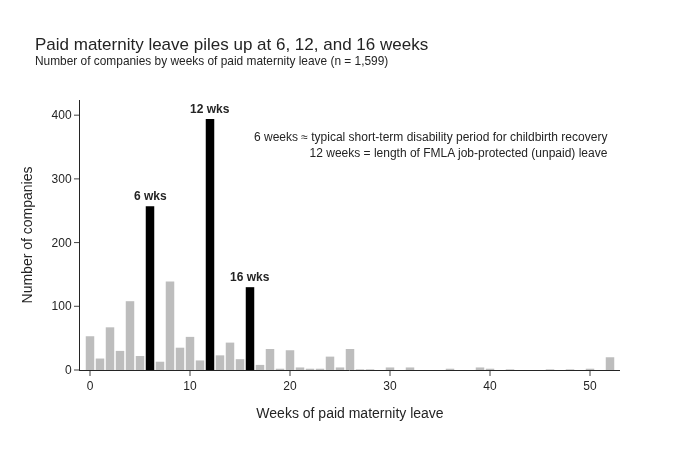

In [17]:
# Round fractional values (e.g., 7.5 weeks, the median of conflicting reports) to the nearest week for plotting
mat_weeks = (df['Paid Maternity Leave'].round()
             .value_counts()
             .rename_axis('Weeks')
             .reset_index(name='Companies')
             .sort_values('Weeks'))
mat_weeks['Share (%)'] = (mat_weeks['Companies'] / mat_weeks['Companies'].sum() * 100).round(1)
mat_weeks['Highlight'] = mat_weeks['Weeks'].isin([6, 12, 16]).map({True: 'Common policy length', False: 'Other'})

fig = px.bar(
    mat_weeks, x='Weeks', y='Companies', color='Highlight',
    color_discrete_map={'Common policy length': 'black', 'Other': GRAY},
    hover_data=['Share (%)'],
    title=f'Paid maternity leave piles up at 6, 12, and 16 weeks<br><sup>Number of companies by weeks of paid maternity leave (n = {len(df):,})</sup>',
    labels={'Weeks': 'Weeks of paid maternity leave', 'Companies': 'Number of companies'},
)
fig.update_traces(marker_line_width=0)
fig.update_layout(showlegend=False, bargap=0.15, height=450, xaxis_range=[-1, 53])
for w in [6, 12, 16]:
    fig.add_annotation(x=w, y=mat_weeks.set_index('Weeks').loc[w, 'Companies'], text=f'<b>{w} wks</b>',
                       showarrow=False, yshift=10)
fig.add_annotation(x=52, y=380, xanchor='right', yanchor='top', align='right', showarrow=False,
                   text='6 weeks ≈ typical short-term disability period for childbirth recovery<br>'
                        '12 weeks = length of FMLA job-protected (unpaid) leave')
fig.show()

In [18]:
mat = df['Paid Maternity Leave']
pd.DataFrame({
    'Share of companies (%)': [
        (mat == 0).mean(), (mat == 6).mean(), (mat == 12).mean(), (mat == 16).mean(),
        mat.isin([6, 12, 16]).mean(), (mat < 12).mean(), (mat > 12).mean(), (mat >= 26).mean(),
    ]
}, index=['0 weeks', 'Exactly 6 weeks', 'Exactly 12 weeks', 'Exactly 16 weeks', 'Exactly 6, 12, or 16 weeks',
          'Under 12 weeks', 'Over 12 weeks', '26 weeks or more']).mul(100).round(1)

,Share of companies (%)
0 weeks,3.3
Exactly 6 weeks,15.9
Exactly 12 weeks,24.3
Exactly 16 weeks,8.0
"Exactly 6, 12, or 16 weeks",48.2
Under 12 weeks,50.8
Over 12 weeks,24.9
26 weeks or more,4.8


Paid maternity leave is not spread smoothly. It piles up at a few standard policy lengths: **48.2%** of companies offer exactly 6, 12, or 16 weeks, and 12 weeks alone accounts for **24.3%** (6 weeks: 15.9%; 16 weeks: 8.0%). These spikes match familiar benchmarks. Six weeks is the usual short-term disability period for recovering from a vaginal birth (8 weeks for a C-section), and 12 weeks matches the FMLA's 12 weeks of job-protected leave.

Even so, **half of the companies (50.8%) offer less than 12 paid weeks**, 3.3% offer none at all, and only 4.8% offer 26 weeks or more.

### 2. How do mothers and fathers compare at the same company?

From here on, comparisons use the 287 companies that report both paid maternity and paid paternity leave.

In [19]:
paired_summary = pd.DataFrame({
    'Mothers': paired['Paid Maternity Leave'].agg(['median', 'mean']),
    'Fathers': paired['Paid Paternity Leave'].agg(['median', 'mean']),
}).round(1)
paired_summary.loc['% offering 0 paid weeks'] = [
    round((paired['Paid Maternity Leave'] == 0).mean() * 100, 1),
    round((paired['Paid Paternity Leave'] == 0).mean() * 100, 1),
]
display(paired_summary)

display((paired['Policy'].value_counts(normalize=True) * 100).round(1).rename('% of companies').to_frame())

wilcoxon = stats.wilcoxon(paired['Paid Maternity Leave'], paired['Paid Paternity Leave'])
print(f'Wilcoxon signed-rank test (mothers vs. fathers at the same company) p-value: {wilcoxon.pvalue:.1e}')
print(f"Equal policies: {(paired['Policy'] == 'Equal').sum()} companies, "
      f"of which {paired['Both zero'].sum()} offer 0 paid weeks to both parents")

,Mothers,Fathers
median,12.0,6.0
mean,11.1,7.2
% offering 0 paid weeks,4.2,11.1


,% of companies
Policy,
Mothers get more,60.3
Equal,33.1
Fathers get more,6.6


Wilcoxon signed-rank test (mothers vs. fathers at the same company) p-value: 7.0e-26
Equal policies: 95 companies, of which 12 offer 0 paid weeks to both parents


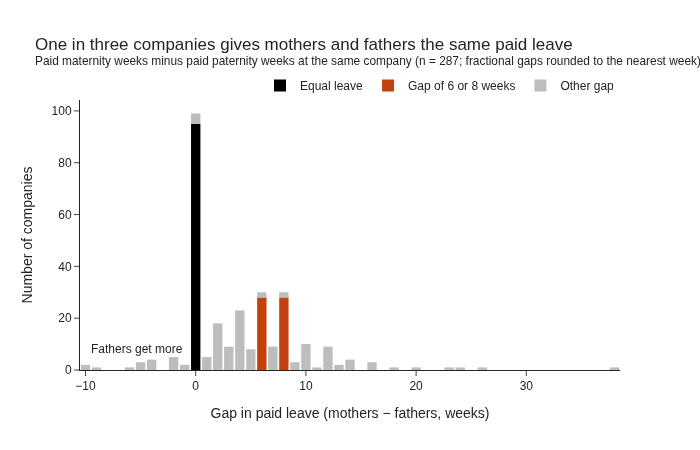

Most common gaps (weeks): {0.0: 95, 6.0: 28, 8.0: 28, 4.0: 20}
Share of companies whose gap is exactly 6 or 8 weeks: 19.5%


In [20]:
# Color by the exact gap; round only the x-position so fractional gaps (e.g., 0.5 weeks) still get a bar
paired['Gap group'] = np.select(
    [paired['Gap (weeks)'] == 0, paired['Gap (weeks)'].isin([6, 8])],
    ['Equal leave', 'Gap of 6 or 8 weeks'],
    default='Other gap',
)
gap_counts = (paired.assign(**{'Gap (weeks)': paired['Gap (weeks)'].round()})
              .groupby(['Gap (weeks)', 'Gap group'], as_index=False)
              .agg(Companies=('Company', 'size')))

fig = px.bar(
    gap_counts, x='Gap (weeks)', y='Companies', color='Gap group',
    color_discrete_map={'Equal leave': 'black', 'Gap of 6 or 8 weeks': MOM_COLOR, 'Other gap': GRAY},
    category_orders={'Gap group': ['Equal leave', 'Gap of 6 or 8 weeks', 'Other gap']},
    title=f'One in three companies gives mothers and fathers the same paid leave<br><sup>Paid maternity weeks minus paid paternity weeks at the same company (n = {len(paired)}; fractional gaps rounded to the nearest week)</sup>',
    labels={'Gap (weeks)': 'Gap in paid leave (mothers − fathers, weeks)', 'Companies': 'Number of companies'},
)
fig.update_traces(marker_line_width=0)
fig.update_layout(bargap=0.15, height=450, legend_title_text='',
                  legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.add_annotation(x=-1, y=gap_counts.query('`Gap (weeks)` < 0')['Companies'].max() + 3,
                   text='Fathers get more', showarrow=False, xanchor='right')
fig.show()

print('Most common gaps (weeks):', paired['Gap (weeks)'].value_counts().head(4).to_dict())
recovery_gap = paired['Gap (weeks)'].isin([6, 8]).mean() * 100
print(f'Share of companies whose gap is exactly 6 or 8 weeks: {recovery_gap:.1f}%')

At the same companies, mothers get a median of **12 paid weeks** and fathers **6** (means of 11.1 vs. 7.2 weeks; Wilcoxon signed-rank p = 7.0e-26). **60.3%** of companies give mothers more paid leave, **33.1%** give both parents the same, and **6.6%** give fathers more. Fathers are also more likely to get nothing: 11.1% of companies offer 0 paid paternity weeks, vs. 4.2% for maternity. Not every equal policy is generous, either: 12 of the 95 equal policies give **0 paid weeks to both parents**.

The shape of the gap is revealing. After the spike at 0, the two most common gaps are exactly **6 and 8 weeks** (28 companies each, 19.5% combined), the standard short-term disability periods for vaginal and C-section births. That fits a common policy design in which both parents receive the same "bonding" leave and birth mothers get paid medical recovery time on top. The data can't confirm this design company by company, but it suggests that part of the measured gap is childbirth recovery rather than unequal treatment of parents as caregivers.

### 3. Does generous maternity leave come with generous paternity leave?

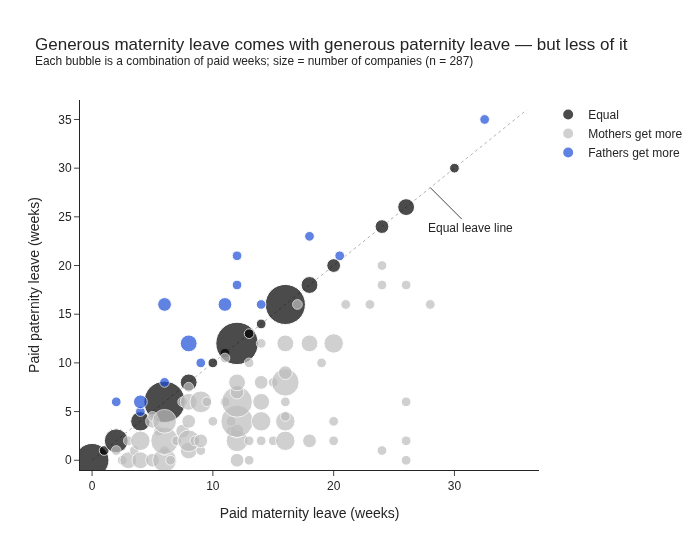

Spearman correlation between paid maternity and paid paternity weeks: 0.60 (p = 5.2e-30)


In [21]:
# Aggregate identical (maternity, paternity) combinations into bubbles instead of plotting overlapping points
combos = paired.groupby(['Paid Maternity Leave', 'Paid Paternity Leave', 'Policy'], as_index=False).agg(
    Companies=('Company', 'size'))

fig = px.scatter(
    combos, x='Paid Maternity Leave', y='Paid Paternity Leave', size='Companies', color='Policy',
    color_discrete_map={'Equal': 'black', 'Mothers get more': GRAY, 'Fathers get more': DAD_COLOR},
    category_orders={'Policy': ['Equal', 'Mothers get more', 'Fathers get more']},
    size_max=30,
    title=f'Generous maternity leave comes with generous paternity leave — but less of it<br><sup>Each bubble is a combination of paid weeks; size = number of companies (n = {len(paired)})</sup>',
    labels={'Paid Maternity Leave': 'Paid maternity leave (weeks)', 'Paid Paternity Leave': 'Paid paternity leave (weeks)'},
)
fig.add_shape(type='line', x0=0, y0=0, x1=36, y1=36, line=dict(color='black', dash='dot', width=1), layer='below')
fig.add_annotation(x=28, y=28, text='Equal leave line', showarrow=True, arrowhead=0, ax=40, ay=40)
fig.update_layout(height=550, legend_title_text='', xaxis_range=[-1, 37], yaxis_range=[-1, 37])
fig.update_traces(marker_line_color='white', marker_line_width=1)
fig.show()

rho = stats.spearmanr(paired['Paid Maternity Leave'], paired['Paid Paternity Leave'])
print(f'Spearman correlation between paid maternity and paid paternity weeks: {rho.statistic:.2f} (p = {rho.pvalue:.1e})')

In [22]:
band_edges = [-0.1, 0.5, 5.5, 11.5, 15.5, np.inf]
band_labels = ['0 weeks', '1–5 weeks', '6–11 weeks', '12–15 weeks', '16+ weeks']
paired['Maternity band'] = pd.cut(paired['Paid Maternity Leave'], band_edges, labels=band_labels)

bands = paired.groupby('Maternity band', as_index=False, observed=True).agg(
    companies=('Company', 'size'),
    median_maternity=('Paid Maternity Leave', 'median'),
    median_paternity=('Paid Paternity Leave', 'median'),
    mean_gap=('Gap (weeks)', 'mean'),
    pct_equal=('Policy', lambda s: (s == 'Equal').mean() * 100),
    pct_zero_paternity=('Paid Paternity Leave', lambda s: (s == 0).mean() * 100),
)
# Fathers' weeks as a share of mothers' weeks (total paternity weeks / total maternity weeks)
totals = paired.groupby('Maternity band', observed=True)[['Paid Paternity Leave', 'Paid Maternity Leave']].sum()
bands['paternity_as_pct_of_maternity'] = (totals['Paid Paternity Leave'] / totals['Paid Maternity Leave'] * 100).values
bands.round(1)

,Maternity band,companies,median_maternity,median_paternity,mean_gap,pct_equal,pct_zero_paternity,paternity_as_pct_of_maternity
0,0 weeks,12,0.0,0.0,0.0,100.0,100.0,NaN
1,1–5 weeks,35,4.0,2.0,1.2,31.4,25.7,65.4
2,6–11 weeks,87,7.0,6.0,2.3,26.4,8.0,68.7
3,12–15 weeks,75,12.0,6.0,5.1,28.0,4.0,59.2
4,16+ weeks,78,16.0,12.0,6.5,35.9,1.3,66.1


Paid maternity and paternity leave move together (Spearman ρ = 0.60): companies that are generous to mothers tend to be generous to fathers. Even so, the gap in weeks **widens** as policies get more generous, from a mean of 1.2 weeks at companies offering 1–5 paid maternity weeks to **6.5 weeks** at those offering 16+. Fathers get roughly 59–69% of mothers' paid weeks at every level, so a bigger maternity policy also means a bigger absolute gap.

The gap is closest to closed at the top of the range. **35.9%** of companies offering 16+ weeks give fathers the same paid leave, the highest share of any band (26.4–31.4% for 1–15 weeks). Only 1.3% of these companies give fathers nothing, vs. 25.7% of companies offering mothers 1–5 weeks. The 12 companies in the 0-week band are "equal" only because neither parent gets any paid leave.

## 🏢 Part 2: Which Industries Are Most Generous, and Where Is the Gap Closing?

### 4. Which industries offer mothers the most paid leave?

This uses all 1,599 companies (paid maternity leave is reported for every company). Only industries with at least 15 companies are shown.

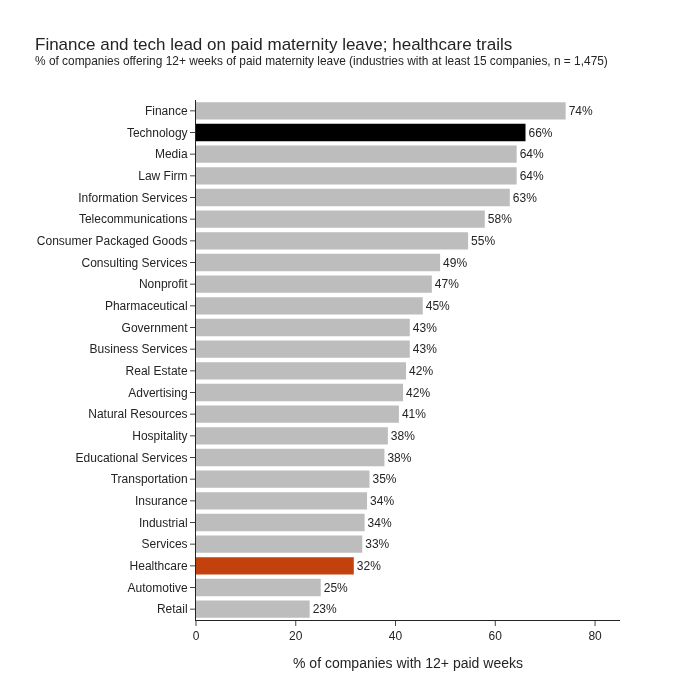

,Industry,companies,median_weeks,pct_12_plus,pct_zero
17,Finance,112,12.0,74.1,0.9
43,Technology,327,12.0,66.1,0.9
24,Law Firm,28,12.0,64.3,3.6
28,Media,28,12.0,64.3,0.0
19,Healthcare,98,6.0,31.6,14.3
4,Automotive,16,6.8,25.0,6.2
39,Retail,79,8.0,22.8,3.8


In [23]:
industry_mat = df.groupby('Industry', as_index=False).agg(
    companies=('Company', 'size'),
    median_weeks=('Paid Maternity Leave', 'median'),
    pct_12_plus=('Paid Maternity Leave', lambda s: (s >= 12).mean() * 100),
    pct_zero=('Paid Maternity Leave', lambda s: (s == 0).mean() * 100),
).query('companies >= 15').sort_values('pct_12_plus')

industry_mat['Highlight'] = np.select(
    [industry_mat['Industry'] == 'Technology', industry_mat['Industry'] == 'Healthcare'],
    ['Technology', 'Healthcare'], default='Other')

fig = px.bar(
    industry_mat, x='pct_12_plus', y='Industry', orientation='h', color='Highlight',
    color_discrete_map={'Technology': 'black', 'Healthcare': MOM_COLOR, 'Other': GRAY},
    hover_data=['companies', 'median_weeks', 'pct_zero'],
    text=industry_mat['pct_12_plus'].round(0).astype(int).astype(str) + '%',
    title=f'Finance and tech lead on paid maternity leave; healthcare trails<br><sup>% of companies offering 12+ weeks of paid maternity leave (industries with at least 15 companies, n = {industry_mat["companies"].sum():,})</sup>',
    labels={'pct_12_plus': '% of companies with 12+ paid weeks', 'Industry': ''},
)
fig.update_traces(textposition='outside', cliponaxis=False, marker_line_width=0)
fig.update_layout(showlegend=False, height=700, xaxis_range=[0, 85])
fig.update_yaxes(categoryorder='array', categoryarray=industry_mat['Industry'])
fig.show()

industry_mat.drop(columns='Highlight').sort_values('pct_12_plus', ascending=False).round(1).iloc[[0, 1, 2, 3, -3, -2, -1]]

Across the 24 industries with at least 15 companies (1,475 companies in total), **finance (74.1%)** and **technology (66.1%)** are the most likely to offer mothers 12+ paid weeks, followed by law firms and media (64.3% each). Healthcare (31.6%), automotive (25.0%), and retail (22.8%) are at the bottom; these industries employ many hourly and shift workers. Healthcare is the most striking case. The industry that cares for new mothers has a median of just **6 paid weeks**, and **14.3%** of healthcare employers report no paid maternity leave at all (vs. 0.9% in finance and in tech).

### 5. Is the gap closing in technology?

Only three industries have at least 15 companies that report both policies (technology, finance, and healthcare), so the remaining industries are pooled.

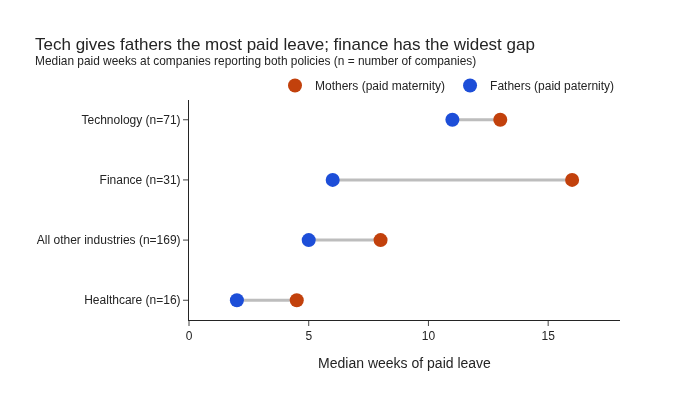

,Industry group,companies,median_maternity,median_paternity,mean_gap,pct_equal,pct_zero_for_both,pct_zero_paternity,paternity_as_pct_of_maternity
0,Healthcare,16,4.5,2.0,2.4,50.0,18.8,43.8,62.4
1,All other industries,169,8.0,5.0,3.8,29.0,4.7,12.4,61.7
2,Finance,31,16.0,6.0,5.9,29.0,0.0,0.0,60.6
3,Technology,71,13.0,11.0,3.9,40.8,1.4,5.6,71.6


In [24]:
# Only three industries have 15+ companies that report paternity leave; pool the rest
paired['Industry group'] = np.where(paired['Industry'].isin(['Technology', 'Finance', 'Healthcare']),
                                    paired['Industry'], 'All other industries')

industry_gap = paired.groupby('Industry group', as_index=False).agg(
    companies=('Company', 'size'),
    median_maternity=('Paid Maternity Leave', 'median'),
    median_paternity=('Paid Paternity Leave', 'median'),
    mean_maternity=('Paid Maternity Leave', 'mean'),
    mean_paternity=('Paid Paternity Leave', 'mean'),
    mean_gap=('Gap (weeks)', 'mean'),
    pct_equal=('Policy', lambda s: (s == 'Equal').mean() * 100),
    pct_zero_for_both=('Both zero', lambda s: s.mean() * 100),
    pct_zero_paternity=('Paid Paternity Leave', lambda s: (s == 0).mean() * 100),
)
industry_gap['paternity_as_pct_of_maternity'] = industry_gap['mean_paternity'] / industry_gap['mean_maternity'] * 100
industry_gap = industry_gap.sort_values('median_paternity').reset_index(drop=True)

fig = go.Figure()
for _, row in industry_gap.iterrows():
    fig.add_trace(go.Scatter(x=[row['median_paternity'], row['median_maternity']], y=[row['Industry group']] * 2,
                             mode='lines', line=dict(color=GRAY, width=3), showlegend=False, hoverinfo='skip'))
fig.add_trace(go.Scatter(x=industry_gap['median_maternity'], y=industry_gap['Industry group'], mode='markers',
                         name='Mothers (paid maternity)', marker=dict(color=MOM_COLOR, size=14)))
fig.add_trace(go.Scatter(x=industry_gap['median_paternity'], y=industry_gap['Industry group'], mode='markers',
                         name='Fathers (paid paternity)', marker=dict(color=DAD_COLOR, size=14)))
fig.update_layout(
    title='Tech gives fathers the most paid leave; finance has the widest gap<br><sup>Median paid weeks at companies reporting both policies (n = number of companies)</sup>',
    xaxis_title='Median weeks of paid leave', yaxis_title='', height=400, xaxis_range=[0, 18],
    yaxis=dict(tickmode='array', tickvals=industry_gap['Industry group'],
               ticktext=[f'{g} (n={n})' for g, n in zip(industry_gap['Industry group'], industry_gap['companies'])]),
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1),
)
fig.show()

industry_gap.drop(columns=['mean_maternity', 'mean_paternity']).round(1)

In [25]:
is_tech = paired['Industry'] == 'Technology'
tests = pd.DataFrame({
    'Technology': [paired.loc[is_tech, 'Paid Paternity Leave'].median(), paired.loc[is_tech, 'Gap (weeks)'].mean(),
                   (paired.loc[is_tech, 'Policy'] == 'Equal').mean() * 100],
    'All non-tech': [paired.loc[~is_tech, 'Paid Paternity Leave'].median(), paired.loc[~is_tech, 'Gap (weeks)'].mean(),
                     (paired.loc[~is_tech, 'Policy'] == 'Equal').mean() * 100],
    'p-value': [
        stats.mannwhitneyu(paired.loc[is_tech, 'Paid Paternity Leave'], paired.loc[~is_tech, 'Paid Paternity Leave']).pvalue,
        stats.mannwhitneyu(paired.loc[is_tech, 'Gap (weeks)'], paired.loc[~is_tech, 'Gap (weeks)']).pvalue,
        stats.fisher_exact(pd.crosstab(is_tech, paired['Policy'] == 'Equal')).pvalue,
    ],
}, index=['Median paid paternity (weeks)', 'Mean gap (weeks)', '% with equal leave'])
tests['Test'] = ['Mann-Whitney U', 'Mann-Whitney U', "Fisher's exact"]
tests[['Technology', 'All non-tech']] = tests[['Technology', 'All non-tech']].round(1)
tests['p-value'] = tests['p-value'].map(lambda p: f'{p:.2g}')
tests

,Technology,All non-tech,p-value,Test
Median paid paternity (weeks),11.0,4.5,5.8e-05,Mann-Whitney U
Mean gap (weeks),3.9,4.0,0.85,Mann-Whitney U
% with equal leave,40.8,30.6,0.11,Fisher's exact


**Technology is the most generous industry for fathers.** The median tech company in the paired sample gives fathers **11 paid weeks**, vs. 4.5 weeks at non-tech companies (Mann-Whitney p = 5.8e-05), and fathers get **71.6%** of mothers' paid weeks on average, vs. 60.6–62.4% in the other groups. The test results add a caveat, though. Tech is generous to mothers too, so its mean gap in weeks is no smaller than elsewhere (3.9 vs. 4.0 weeks; p = 0.85). Its higher share of equal policies (40.8% vs. 30.6%) is also not statistically significant (Fisher's exact p = 0.11). The medians in the chart (13 vs. 11 weeks) make tech's gap look nearly closed. A fair summary is that tech is closing the gap **in proportion, not yet in weeks**.

**Finance** offers the most generous maternity leave of the four groups (median 16 weeks), but fathers get a median of only 6, the widest median gap (mean gap 5.9 weeks). **Healthcare** (only 16 companies) shows why "equal" isn't the same as "generous". Half of its policies are equal, but 18.8% of these healthcare companies give *neither* parent any paid leave, and 43.8% give fathers 0 paid weeks.

## 🗓️ Part 3: Unpaid Leave and Standout Employers

### 6. Do companies substitute unpaid leave for paid leave?

Unpaid *paternity* leave is blank for 96% of companies, so this section looks only at mothers (the 1,492 companies that report both paid and unpaid maternity leave).

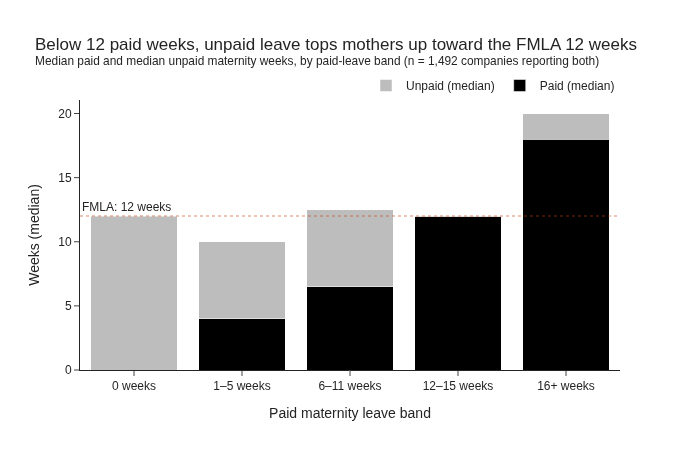

Spearman correlation, paid vs. unpaid maternity weeks: -0.15 (p = 9.8e-09)


,Paid band,companies,median_paid,median_unpaid,median_total,pct_no_unpaid,pct_total_12_plus
0,0 weeks,31,0.0,12.0,12.0,19.4,61.3
1,1–5 weeks,231,4.0,6.0,10.0,20.3,45.0
2,6–11 weeks,494,6.5,6.0,12.0,25.5,65.4
3,12–15 weeks,450,12.0,0.0,14.0,50.4,100.0
4,16+ weeks,286,18.0,2.0,24.0,46.5,100.0


In [26]:
unpaid = df.dropna(subset=['Unpaid Maternity Leave']).copy()
unpaid['Total maternity leave'] = unpaid['Paid Maternity Leave'] + unpaid['Unpaid Maternity Leave']
unpaid['Paid band'] = pd.cut(unpaid['Paid Maternity Leave'], band_edges, labels=band_labels)

unpaid_bands = unpaid.groupby('Paid band', as_index=False, observed=True).agg(
    companies=('Company', 'size'),
    median_paid=('Paid Maternity Leave', 'median'),
    median_unpaid=('Unpaid Maternity Leave', 'median'),
    median_total=('Total maternity leave', 'median'),
    pct_no_unpaid=('Unpaid Maternity Leave', lambda s: (s == 0).mean() * 100),
    pct_total_12_plus=('Total maternity leave', lambda s: (s >= 12).mean() * 100),
)

fig = go.Figure()
fig.add_trace(go.Bar(x=unpaid_bands['Paid band'], y=unpaid_bands['median_paid'], name='Paid (median)',
                     marker_color='black'))
fig.add_trace(go.Bar(x=unpaid_bands['Paid band'], y=unpaid_bands['median_unpaid'], name='Unpaid (median)',
                     marker_color=GRAY))
fig.add_hline(y=12, line_dash='dot', line_color=MOM_COLOR, line_width=2, layer='above',
              annotation_text='FMLA: 12 weeks', annotation_position='top left')
fig.update_layout(
    barmode='stack', height=450,
    title=f'Below 12 paid weeks, unpaid leave tops mothers up toward the FMLA 12 weeks<br><sup>Median paid and median unpaid maternity weeks, by paid-leave band (n = {len(unpaid):,} companies reporting both)</sup>',
    xaxis_title='Paid maternity leave band', yaxis_title='Weeks (median)',
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1),
)
fig.show()

rho_unpaid = stats.spearmanr(unpaid['Paid Maternity Leave'], unpaid['Unpaid Maternity Leave'])
print(f'Spearman correlation, paid vs. unpaid maternity weeks: {rho_unpaid.statistic:.2f} (p = {rho_unpaid.pvalue:.1e})')
unpaid_bands.round(1)

In [27]:
below_12 = unpaid.query('`Paid Maternity Leave` < 12')
print(f'Companies with < 12 paid weeks: {len(below_12):,}')
print(f'  ...whose paid + unpaid total is exactly 12 weeks: {(below_12["Total maternity leave"] == 12).mean():.1%}')
print(f'  ...whose paid + unpaid total reaches at least 12 weeks: {(below_12["Total maternity leave"] >= 12).mean():.1%}')

Companies with < 12 paid weeks: 756
  ...whose paid + unpaid total is exactly 12 weeks: 26.3%
  ...whose paid + unpaid total reaches at least 12 weeks: 59.0%


Paid and unpaid maternity leave are only weak substitutes (Spearman ρ = −0.15), but the pattern by band is clear. Companies with **no** paid maternity leave typically offer 12 unpaid weeks, and those with 1–11 paid weeks typically add 6 unpaid weeks, for a median total of 10–12 weeks. Of the **756 companies with fewer than 12 paid weeks**, 59.0% reach at least 12 weeks in total and **26.3% land on exactly 12**, the FMLA's job-protected minimum for eligible U.S. employees. Once paid leave reaches 12 weeks, unpaid leave largely disappears: **half (50.4%)** of companies offering 12–15 paid weeks offer no unpaid leave at all.

In short, unpaid leave mostly fills the gap up to the legal floor and adds little to already generous policies. It also doesn't reach 12 weeks for the 41.0% of low-paid-leave companies that stay below that level. (The chart stacks median paid and median unpaid weeks; the table shows the median *total* for each band.)

### 7. Which employers stand out?

The 15 companies with the most paid paternity leave (ties broken by paid maternity leave):

In [28]:
standouts = (paired.sort_values(['Paid Paternity Leave', 'Paid Maternity Leave'], ascending=False)
             .head(15)[['Company', 'Industry', 'Paid Maternity Leave', 'Paid Paternity Leave', 'Policy']]
             .reset_index(drop=True))
standouts.index = standouts.index + 1
standouts

,Company,Industry,Paid Maternity Leave,Paid Paternity Leave,Policy
1,LAC-Group,Information Services,32.5,35.0,Fathers get more
2,Flatiron Health,Healthcare,30.0,30.0,Equal
3,Bill and Melinda Gates Foundation,Philanthropy,26.0,26.0,Equal
4,Hewlett Packard Enterprise,Technology,26.0,26.0,Equal
5,Salesforce,Technology,26.0,26.0,Equal
6,Dropbox,Technology,24.0,24.0,Equal
7,Start Early,Nonprofit,24.0,24.0,Equal
8,S&P Global,Information Services,18.0,23.0,Fathers get more
9,Bain & Company,Consulting Services,20.5,21.0,Fathers get more
10,Fairygodboss Inc.,Technology,12.0,21.0,Fathers get more


In [29]:
print(f"Companies where fathers get more paid leave than mothers: {(paired['Policy'] == 'Fathers get more').sum()}")
paired.query('Policy == "Fathers get more"').sort_values('Gap (weeks)')[
    ['Company', 'Industry', 'Paid Maternity Leave', 'Paid Paternity Leave', 'Gap (weeks)']
].head(8)

Companies where fathers get more paid leave than mothers: 19


,Company,Industry,Paid Maternity Leave,Paid Paternity Leave,Gap (weeks)
58,ADP,Business Services,6.0,16.0,-10.0
171,Consumers Energy,Natural Resources,6.0,16.0,-10.0
32,Fairygodboss Inc.,Technology,12.0,21.0,-9.0
90,Capital Group,Finance,12.0,18.0,-6.0
91,Merrill,Finance,11.0,16.0,-5.0
147,S&P Global,Information Services,18.0,23.0,-5.0
257,Zoom,Telecommunications,11.0,16.0,-5.0
50,Cessna Aircraft Company,Aerospace,8.0,12.0,-4.0


The most generous paternity policies are mostly gender-neutral. **12 of the top 15 companies give fathers at least as much paid leave as mothers** (8 equal, 4 with more for fathers), and 7 of the 15 are tech companies. Flatiron Health (30 weeks), the Bill and Melinda Gates Foundation, Hewlett Packard Enterprise, and Salesforce (26 weeks each) offer equal paid leave at roughly six months or more.

Across the paired sample, **19 companies (6.6%)** report more paid leave for fathers than for mothers. These are worth a second look before anyone cites them. Few employers intend to give fathers more than mothers, so a reversed gap can mean that one of the two numbers was reported inconsistently (for example, a mother's entry that captures only disability pay). The largest reversals are ADP and Consumers Energy (6 vs. 16 weeks). Fairygodboss, the data source itself, reports 12 weeks for mothers vs. 21 for fathers.

## Key Findings

- **A blank is not a zero.** Paid paternity leave is missing for 81.9% of companies. Filling the blanks with 0 would put the median paternity leave at 0 weeks instead of 6. The 287 companies that report both policies are also somewhat more generous to mothers than the rest (median 12 vs. 10 paid weeks; p = 0.014).
- **Mothers get twice the median paid leave of fathers.** At the same companies, the median is 12 paid weeks for mothers and 6 for fathers. 60.3% of companies give mothers more, 33.1% give both parents the same, and 6.6% give fathers more.
- **Policies cluster at benchmark lengths.** 48.2% of companies offer exactly 6, 12, or 16 paid maternity weeks (12 weeks alone: 24.3%), and half (50.8%) offer less than 12. 19.5% of mother–father gaps are exactly 6 or 8 weeks, the usual disability recovery periods. That suggests part of the gap is medical recovery added on top of equal bonding leave.
- **The gap in weeks grows with generosity, while parity is most common at the top.** Fathers get about 59–69% of mothers' paid weeks at every level, so the mean gap rises from 1.2 weeks (1–5 maternity weeks) to 6.5 weeks (16+). The share of equal policies is highest among companies offering 16+ weeks (35.9%).
- **Tech leads for fathers, finance has the widest gap, and healthcare trails.** Tech gives fathers a median of 11 paid weeks vs. 4.5 elsewhere (p < 0.001), but its mean gap is no smaller (3.9 vs. 4.0 weeks). Finance pairs a median of 16 maternity weeks with 6 paternity weeks. Healthcare is near the bottom: 31.6% of healthcare employers offer mothers 12+ paid weeks (vs. 74.1% in finance), and 14.3% offer no paid maternity leave.
- **Unpaid leave mostly brings mothers up to the FMLA's 12 weeks.** Of the companies offering fewer than 12 paid weeks, 59.0% reach 12+ weeks with unpaid leave and 26.3% land on exactly 12. Among companies offering 12–15 paid weeks, 50.4% offer no unpaid leave.

## Case Study Potential

**Verdict: Strong** (for an introductory pandas or data-cleaning course). The dataset is small, clean in structure, and relatable, and it contains a real trap: treating a blank as zero changes the headline conclusion. It also has clear policy benchmarks (6/12/16 weeks, FMLA) that explain the patterns, plus a selection-bias question that students can test. It is less suited to advanced modeling: there is no time dimension, no company size, and no outcome variable.

**Suggested framing.** You are the benefits lead at a mid-size tech company that offers 12 weeks of paid maternity leave and 4 weeks of paid paternity leave. Leadership asks: *How does our policy compare with peers? Is a gender-neutral policy now the norm? What would it take to be competitive for both parents?* Students benchmark the policy, check how far they can trust the crowdsourced data, and recommend a change (e.g., equal 16 weeks of bonding leave plus medical recovery time for birth mothers).

**Analytics skills exercised:** interpreting missing data (`NaN` vs. 0), string splitting and cleaning, de-duplication with `groupby`, `groupby(...).agg(...)` with named and custom aggregations, binning with `pd.cut`, `value_counts`, paired vs. unpaired comparisons, nonparametric tests (Wilcoxon, Mann-Whitney, Fisher's exact), selection bias, and emphasis-by-contrast visualization.

**Candidate student questions**
1. What is the median paid paternity leave if blanks are filled with 0? If blanks are excluded? Which is correct, and why?
2. Among companies that report both policies, what share give mothers and fathers equal paid leave? How many of those "equal" policies offer 0 weeks?
3. Which industries (with at least 15 companies) are most and least likely to offer 12+ weeks of paid maternity leave? What might explain where healthcare ranks?
4. Do companies with less paid leave offer more unpaid leave? How does the FMLA help explain the pattern?
5. Where would a 12-week maternity / 4-week paternity policy rank among tech peers, and what change would make it both gender-neutral and competitive?

**Main data limitations:** the data are self-reported and crowdsourced on a career site for women, so they are not a random sample of employers or employees. 82% of companies have no paternity data, and the companies that do report it skew more generous. There is a single snapshot with no dates, so "closing the gap" can only be inferred across companies, not observed over time. Company size, location, and eligibility rules are unknown, and U.S. and non-U.S. employers are mixed together. Maternity figures may blend disability pay with bonding leave, adoptive and non-birthing parents are not covered, and values that users disagreed on are medians of their reports.